# Model Predictive Control System Design and Implementation  
### Using Python  

*Based on the book by Liuping Wang*  
**Written by Samuel Giwa Boluwatife**  

---

This notebook presents the implementation of **Model Predictive Control (MPC)** concepts using **Python**. The methodology is inspired by the book *Model Predictive Control System Design and Implementation Using MATLAB* by Liuping Wang.  

## Table of Contents  
1. Introduction to Model Predictive Control  
2. System Modeling and State-Space Representation  
3. MPC Problem Formulation  
4. Python Implementation of MPC  
5. Simulation and Performance Analysis  
6. Conclusion  

---

> **Note:** Ensure you have the necessary Python libraries installed, such as:
> ```python
> pip install numpy scipy matplotlib control
> ```
> This notebook uses **NumPy, SciPy, Matplotlib, and Control** for numerical computations and control system design.


In [69]:
import numpy as np
import numpy as np
from mpc import mpcgain  
import matplotlib.pyplot as plt

In [ ]:


def mpcgain(Ap, Bp, Cp, Nc, Np):
    m1, n1 = Cp.shape
    n1, n_in = Bp.shape
    
    A_e = np.eye(n1 + m1, n1 + m1)
    A_e[:n1, :n1] = Ap
    A_e[n1:n1 + m1, :n1] = Cp @ Ap
    
    B_e = np.zeros((n1 + m1, n_in))
    B_e[:n1, :] = Bp
    B_e[n1:n1 + m1, :] = Cp @ Bp
    
    C_e = np.zeros((m1, n1 + m1))
    C_e[:, n1:n1 + m1] = np.eye(m1)
    
    n = n1 + m1
    h = np.zeros((Np, n))
    F = np.zeros((Np, n))
    
    h[0, :] = C_e
    F[0, :] = C_e @ A_e
    
    for kk in range(1, Np):
        h[kk, :] = h[kk - 1, :] @ A_e
        F[kk, :] = F[kk - 1, :] @ A_e
    
    v = h @ B_e
    
    Phi = np.zeros((Np, Nc))
    Phi[:, 0] = v[:, 0]
    
    for i in range(1, Nc):
        Phi[:, i] = np.hstack((np.zeros(i), v[:Np - i, 0]))
    
    BarRs = np.ones((Np, 1))
    
    Phi_Phi = Phi.T @ Phi
    Phi_F = Phi.T @ F
    Phi_R = Phi.T @ BarRs
    
    return Phi_Phi, Phi_F, Phi_R, A_e, B_e, C_e




# TEST AGAINST THAT OF THE TEXT TO ENSURE THE MPC GAIN FUCNTION IS WORKING

Ap = np.array([[0.8]])  
Bp = np.array([[0.1]])  
Cp = np.array([[1]])  
Nc = 4
Np = 10


Phi_Phi, Phi_F, Phi_R, A_e, B_e, C_e = mpcgain(Ap, Bp, Cp, Nc, Np)


print("Phi_Phi:\n", Phi_Phi)
print("Phi_F:\n", Phi_F)
print("Phi_R:\n", Phi_R)
print("A_e:\n", A_e)
print("B_e:\n", B_e)
print("C_e:\n", C_e)

Phi_Phi:
 [[1.15406871 1.04074235 0.91158439 0.77263694]
 [1.04074235 0.9548735  0.84753744 0.72586737]
 [0.91158439 0.84753744 0.76747877 0.66740542]
 [0.77263694 0.72586737 0.66740542 0.59432797]]
Phi_F:
 [[9.23254971 3.21474836]
 [8.32593877 2.76843546]
 [7.2926751  2.33554432]
 [6.18109551 1.9194304 ]]
Phi_R:
 [[3.21474836]
 [2.76843546]
 [2.33554432]
 [1.9194304 ]]
A_e:
 [[0.8 0. ]
 [0.8 1. ]]
B_e:
 [[0.1]
 [0.1]]
C_e:
 [[0. 1.]]


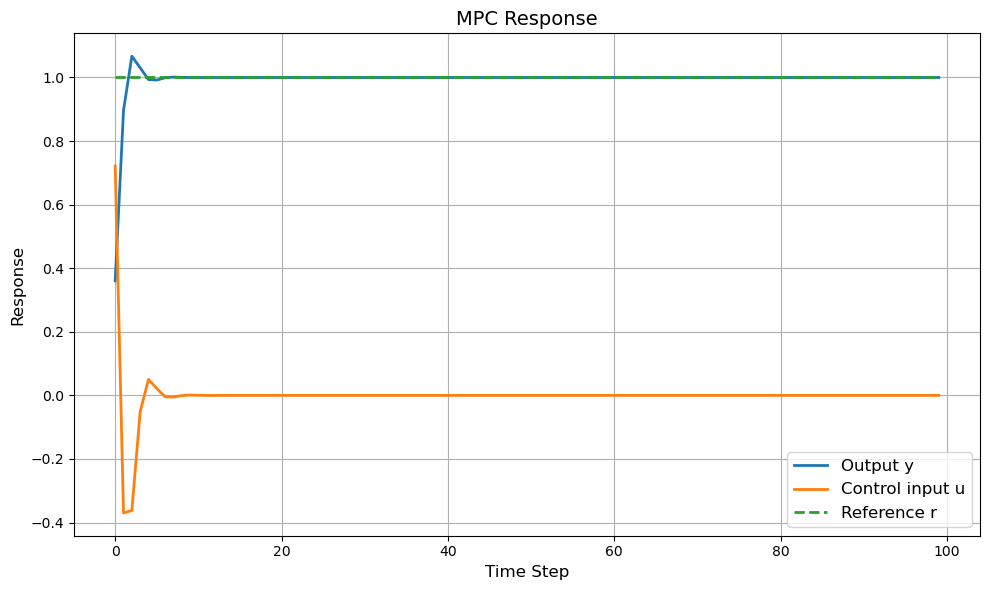

In [75]:
def mpc_control(Ap,Bp,Cp,Dp,Np,Nc):
    Phi_Phi, Phi_F, Phi_R, A_e, B_e, C_e = mpcgain(Ap, Bp, Cp, Nc, Np)


    n, n_in = B_e.shape  


    xm = np.array([[0], [0]])  
    Xf = np.zeros((n, 1))


    N_sim = 100
    r = np.ones((N_sim, 1))  
    u = 0
    y = 0


    u1 = np.zeros((N_sim, 1))
    y1 = np.zeros((N_sim, 1))


    for kk in range(N_sim):
        
    
        DeltaU = np.linalg.inv(Phi_Phi + 0.1 * np.eye(Nc)) @ (Phi_R * r[kk] - Phi_F @ Xf)
        deltau = DeltaU[0, 0]

        
        u = u + deltau

        
        u1[kk] = u

    
        xm_old = xm.copy()

        
        xm = Ap @ xm + Bp * u  

    
        y = Cp @ xm 
        
        
        y1[kk] = y

    
        Xf = np.vstack((xm - xm_old, y))  

    plt.figure(figsize=(10, 6))
    
    plt.plot(np.arange(N_sim), y1, label='Output y', linewidth=2)
    plt.plot(np.arange(N_sim), u1, label='Control input u', linewidth=2)
    plt.plot(np.arange(N_sim), r, '--', label='Reference r', linewidth=2)

    plt.xlabel('Time Step', fontsize=12)
    plt.ylabel('Response', fontsize=12)
    plt.title('MPC Response', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
Ap = np.array([[1, 1],      
               [0, 1]])

Bp = np.array([[0.5], 
               [1]])  

Cp = np.array([[1, 0]])  

Dp = 0  

Np = 20  
Nc = 4 

mpc_control(Ap,Bp,Cp,Dp,Np,Nc)

array([[1435. ],
       [1235. ],
       [1054.5],
       [ 892.5]])